In [ ]:
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import userdata
import os

token = userdata.get('KAGGLE_API_TOKEN')
os.environ['KAGGLE_API_TOKEN'] = token

!kaggle datasets list -s "diabetic retinopathy"

ref                                                           title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
tanlikesmath/diabetic-retinopathy-resized                     Diabetic Retinopathy (resized)                       7785957896  2019-05-08 01:48:17.993000          31599        584  0.5882353        
sovitrath/diabetic-retinopathy-224x224-gaussian-filtered      Diabetic Retinopathy 224x224 Gaussian Filtered        447582906  2020-02-18 02:33:27.540000          26973        249  0.88235295       
sachinkumar413/diabetic-retinopathy-dataset                   Diabetic Retinopathy Dataset                          367332292  2022-04-24 16:55:11.840000           7625         71  0.75             
pkdar

In [ ]:
import os
base_path = 'data/Diagnosis of Diabetic Retinopathy'
print(os.path.exists(base_path))
if os.path.exists(base_path):
    print(os.listdir(base_path))

False


In [ ]:
import os

!kaggle datasets download -d pkdarabi/diagnosis-of-diabetic-retinopathy --quiet
!unzip -q diagnosis-of-diabetic-retinopathy.zip -d data/
print("Downloaded and extracted")
print(os.listdir('data/'))

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/diagnosis-of-diabetic-retinopathy
License(s): MIT
Downloaded and extracted
['Diagnosis of Diabetic Retinopathy', 'retino']


In [ ]:
base_path = 'data/Diagnosis of Diabetic Retinopathy'

print("Top level contents:")
print(os.listdir(base_path))

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    print(f"{indent}{folder_name}/  ({len(files)} files)")

Top level contents:
['valid', 'test', 'train']
Diagnosis of Diabetic Retinopathy/  (0 files)
  valid/  (0 files)
    DR/  (245 files)
    No_DR/  (286 files)
  test/  (0 files)
    DR/  (113 files)
    No_DR/  (118 files)
  train/  (0 files)
    DR/  (1050 files)
    No_DR/  (1026 files)


In [ ]:
import tensorflow as tf

base_path = 'data/Diagnosis of Diabetic Retinopathy'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base_path}/train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base_path}/valid',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{base_path}/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print("Class names:", train_ds.class_names)

Found 2076 files belonging to 2 classes.
Found 531 files belonging to 2 classes.
Found 231 files belonging to 2 classes.
Class names: ['DR', 'No_DR']


In [ ]:
# Normalize pixel values from 0-255 to 0-1, which helps the model train more effectively
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Cache and prefetch for faster training - keeps the GPU fed with data instead of waiting
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data pipeline ready")

Data pipeline ready


In [ ]:
# Load MobileNetV2 pretrained on ImageNet, without its final classification layer
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so we don't retrain its existing learned features
base_model.trainable = False

# Build our own classifier on top
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 49s 484ms/step - accuracy: 0.5954 - loss: 0.6923 - val_accuracy: 0.7401 - val_loss: 0.5685
Epoch 2/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7264 - loss: 0.5560 - val_accuracy: 0.8512 - val_loss: 0.4666
Epoch 3/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8097 - loss: 0.4624 - val_accuracy: 0.8889 - val_loss: 0.3961
Epoch 4/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8502 - loss: 0.4116 - val_accuracy: 0.8927 - val_loss: 0.3494
Epoch 5/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8695 - loss: 0.3762 - val_accuracy: 0.8964 - val_loss: 0.3189
Epoch 6/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8762 - loss: 0.3397 - val_accuracy: 0.9096 - val_loss: 0.2952
Epoch 7/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8887 - loss: 0.3195 - val_accuracy: 0.9134 - val_loss: 0.2761
Epoch 8/10
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8945 - loss: 0.3059 - val_accuracy: 0.9153 -

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest accuracy: {test_accuracy:.2%}")
print(f"Test loss: {test_loss:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8918 - loss: 0.2669

Test accuracy: 89.18%
Test loss: 0.2669


In [ ]:
model.save('diabetic_retinopathy_model.h5')
print("Model saved")

# Also save a backup to Google Drive so it survives a runtime disconnect
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('diabetic_retinopathy_model.h5', '/content/drive/MyDrive/diabetic_retinopathy_model.h5')
print("Backed up to Google Drive")

Model saved
Mounted at /content/drive
Backed up to Google Drive


In [ ]:
# Save in the modern Keras format instead
model.save('diabetic_retinopathy_model.keras')
print("Model saved in native Keras format")

# Update the Drive backup too
shutil.copy('diabetic_retinopathy_model.keras', '/content/drive/MyDrive/diabetic_retinopathy_model.keras')
print("Backed up to Google Drive")

Model saved in native Keras format
Backed up to Google Drive


In [ ]:
import numpy as np

# Get true labels and predictions for the entire test set
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = (y_pred_probs > 0.5).astype(int)

print(f"Total test predictions: {len(y_pred)}")
print(f"Sample predictions (probability, predicted class, actual class):")
for i in range(5):
    print(f"  {y_pred_probs[i]:.3f}  →  predicted: {y_pred[i]}  actual: {int(y_true[i])}")

Total test predictions: 231
Sample predictions (probability, predicted class, actual class):
  0.932  →  predicted: 1  actual: 1
  0.957  →  predicted: 1  actual: 1
  0.109  →  predicted: 0  actual: 0
  0.938  →  predicted: 1  actual: 1
  0.884  →  predicted: 1  actual: 1


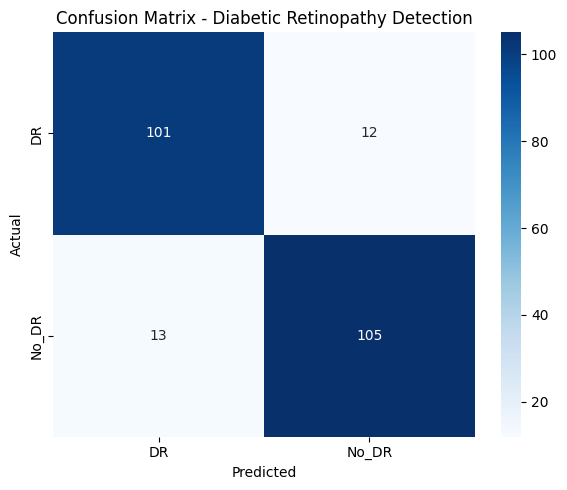


Classification Report:
              precision    recall  f1-score   support

          DR       0.89      0.89      0.89       113
       No_DR       0.90      0.89      0.89       118

    accuracy                           0.89       231
   macro avg       0.89      0.89      0.89       231
weighted avg       0.89      0.89      0.89       231



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DR', 'No_DR'],
            yticklabels=['DR', 'No_DR'])
plt.title('Confusion Matrix - Diabetic Retinopathy Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['DR', 'No_DR']))

In [ ]:
from google.colab import files
files.download('diabetic_retinopathy_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>